# Risk Dependency Classification Model

## Objective
This notebook develops a machine learning model to predict high-risk dependency levels among employees.
We use a RandomForestClassifier with K-Fold cross-validation to classify employees as having high dependency risk or not.

### Key Steps:
1. Load training dataset from environment variable DATA_PATH
2. Create binary target variable (dependency_risk_high)
3. Select numeric features for model training
4. Train RandomForestClassifier with KFold cross-validation (k=5)
5. Evaluate performance metrics (Accuracy, Precision, Recall, ROC-AUC)
6. Visualize feature importance
7. Save trained model for production use

In [1]:
# Import required libraries
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import KFold, cross_validate
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score
import joblib
import warnings
warnings.filterwarnings('ignore')

# Configure visualization settings
plt.style.use('default')
sns.set_palette('husl')
%matplotlib inline

In [2]:
# Load dataset from environment variable
# Get the data path from environment (should point to the survey dataset)
data_path = '/workspaces/EvaluAI/backend/data/raw/EIPIA_FO_dataset_100_personas.csv'

# Check if path exists
if not os.path.exists(data_path):
    raise FileNotFoundError(f"Dataset not found at: {data_path}")

# Load the dataset with semicolon delimiter
df = pd.read_csv(data_path, sep=';')

print(f"Dataset loaded successfully from: {data_path}")
print(f"Dataset shape: {df.shape}")

Dataset loaded successfully from: /workspaces/EvaluAI/backend/data/raw/EIPIA_FO_dataset_100_personas.csv
Dataset shape: (100, 41)


In [3]:
# Display basic dataset information
print("\n=== Dataset Overview ===")
print(f"Total rows: {len(df)}")
print(f"Total columns: {len(df.columns)}")
print(f"\nColumn names and types:")
print(df.dtypes)
print(f"\nFirst few rows:")
df.head()


=== Dataset Overview ===
Total rows: 100
Total columns: 41

Column names and types:
id_empleado                 object
edad                         int64
genero                      object
departamento                object
antiguedad_empresa           int64
nivel_educativo             object
rol_tecnico                  int64
sector                      object
frecuencia_uso_ia            int64
usa_chatgpt                  int64
usa_gemini                   int64
usa_copilot                  int64
usa_lms_ia                   int64
usa_otra_ia                  int64
herramienta_principal       object
prefiere_humano_vs_ia        int64
nivel_integracion_ia         int64
AT1_rendimiento              int64
AT2_facilita_aprendizaje     int64
AT3_facilidad_uso            int64
AT4_integracion_positiva     int64
AE1_resolver_problemas       int64
AE2_confianza_digital        int64
AE3_uso_eficaz               int64
AE4_seguridad_aplicacion     int64
M1_estimulante               int64
M2_au

,id_empleado,edad,genero,departamento,antiguedad_empresa,nivel_educativo,rol_tecnico,sector,frecuencia_uso_ia,usa_chatgpt,...,E3_aplicable_trabajo,E4_aprendizaje_ritmo,D1_mejora_competencias,D2_preparado_retos,D3_amplia_habilidades,D4_aprendizaje_autonomo,C1_confio_sin_verificar,C2_dificil_sin_ia,C3_pensamiento_critico,C4_reflexiono_calidad
0,1XVWCBPH,50,Mujer,IT,17,Máster,0,Servicios,2,1,...,5,6,7,5,7,7,4,3,5,5
1,MMY0MFRF,36,No binario,RRHH,1,FP Superior,1,Tecnología,4,0,...,3,7,7,1,5,2,5,3,1,3
2,5OYF5MXQ,29,Mujer,Marketing,16,Máster,0,Industria,5,0,...,5,7,6,4,2,1,1,2,4,3
3,7FADIBHD,42,No binario,Marketing,12,Máster,1,Servicios,5,1,...,4,1,3,5,2,6,4,6,3,7
4,348YKIFK,40,Hombre,RRHH,19,FP Superior,1,Tecnología,5,1,...,1,4,5,2,4,3,6,6,1,7


In [4]:
# Check for missing values and basic statistics
print("\n=== Missing Values ===")
missing = df.isnull().sum()
if missing.sum() > 0:
    print(missing[missing > 0])
else:
    print("No missing values found")

print("\n=== Statistical Summary ===")
df.describe()


=== Missing Values ===
No missing values found

=== Statistical Summary ===


,edad,antiguedad_empresa,rol_tecnico,frecuencia_uso_ia,usa_chatgpt,usa_gemini,usa_copilot,usa_lms_ia,usa_otra_ia,prefiere_humano_vs_ia,...,E3_aplicable_trabajo,E4_aprendizaje_ritmo,D1_mejora_competencias,D2_preparado_retos,D3_amplia_habilidades,D4_aprendizaje_autonomo,C1_confio_sin_verificar,C2_dificil_sin_ia,C3_pensamiento_critico,C4_reflexiono_calidad
count,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.00,100.000000,100.00,100.000000,...,100.000000,100.000000,100.000000,100.000000,100.00000,100.000000,100.000000,100.000000,100.000000,100.000000
mean,40.060000,9.910000,0.440000,3.150000,0.530000,0.460000,0.55,0.500000,0.45,4.150000,...,3.840000,4.120000,4.400000,3.990000,3.81000,4.020000,3.940000,4.080000,3.800000,3.960000
std,10.688255,5.947744,0.498888,1.539874,0.501614,0.500908,0.50,0.502519,0.50,2.090744,...,1.998585,2.011482,1.938447,1.904248,2.06801,1.906819,1.988959,1.962682,2.025095,1.994538
min,22.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.00,0.000000,0.00,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,30.000000,4.750000,0.000000,2.000000,0.000000,0.000000,0.00,0.000000,0.00,2.000000,...,2.000000,2.000000,3.000000,2.000000,2.00000,3.000000,2.000000,3.000000,2.000000,2.000000
50%,41.500000,10.000000,0.000000,3.000000,1.000000,0.000000,1.00,0.500000,0.00,4.000000,...,4.000000,4.000000,4.000000,4.000000,4.00000,4.000000,4.000000,4.000000,4.000000,4.000000
75%,48.000000,15.000000,1.000000,5.000000,1.000000,1.000000,1.00,1.000000,1.00,6.000000,...,5.250000,6.000000,6.000000,6.000000,6.00000,6.000000,6.000000,6.000000,6.000000,6.000000
max,59.000000,19.000000,1.000000,5.000000,1.000000,1.000000,1.00,1.000000,1.00,7.000000,...,7.000000,7.000000,7.000000,7.000000,7.00000,7.000000,7.000000,7.000000,7.000000,7.000000


In [5]:
# Create binary target variable: dependency_risk_high
# Based on kpi_engine.py calculate_dependency_risk_distribution() logic
# Uses columns C1, C2, C3, C4 (trust/dependency indicators on 1-7 scale)

dependency_cols = ['C1_confio_sin_verificar', 'C2_dificil_sin_ia', 
                   'C3_pensamiento_critico', 'C4_reflexiono_calidad']

# Verify all dependency columns exist
available_dep_cols = [col for col in dependency_cols if col in df.columns]

if len(available_dep_cols) == 4:
    print(f"✓ Found all dependency columns: {available_dep_cols}")
    
    # Make a copy to avoid modifying original
    df_temp = df.copy()
    
    # Invert C3 and C4 (like kpi_engine does: 8 - value)
    df_temp['C3_pensamiento_critico'] = 8 - df_temp['C3_pensamiento_critico']
    df_temp['C4_reflexiono_calidad'] = 8 - df_temp['C4_reflexiono_calidad']
    
    # Calculate mean dependency risk score
    df['dependency_score'] = df_temp[dependency_cols].mean(axis=1)
    
    # Categorize into three levels (matching kpi_engine thresholds)
    # high_risk: > 5.5, medium_risk: 3.5-5.5, low_risk: <= 3.5
    df['dependency_risk_category'] = pd.cut(
        df['dependency_score'],
        bins=[0, 3.5, 5.5, 7],
        labels=['low_risk', 'medium_risk', 'high_risk']
    )
    
    # Create binary target: 1 = high dependency risk, 0 = otherwise
    df['dependency_risk_high'] = (df['dependency_score'] > 5.5).astype(int)
    
    print(f"\nDependency Risk Scoring:")
    print(f"  Mean score: {df['dependency_score'].mean():.2f}")
    print(f"  Std dev: {df['dependency_score'].std():.2f}")
    print(f"  Range: [{df['dependency_score'].min():.2f}, {df['dependency_score'].max():.2f}]")
    
    print(f"\n=== Binary Target Distribution ===")
    print(df['dependency_risk_high'].value_counts())
    print(f"\nClass distribution:")
    print(df['dependency_risk_high'].value_counts(normalize=True))
    
    print(f"\n=== Risk Category Distribution ===")
    print(df['dependency_risk_category'].value_counts())
    print(f"\nProportion:")
    print(df['dependency_risk_category'].value_counts(normalize=True))
else:
    raise ValueError(f"Missing dependency columns! Found: {available_dep_cols}")

✓ Found all dependency columns: ['C1_confio_sin_verificar', 'C2_dificil_sin_ia', 'C3_pensamiento_critico', 'C4_reflexiono_calidad']

Dependency Risk Scoring:
  Mean score: 4.07
  Std dev: 0.97
  Range: [1.75, 6.25]

=== Binary Target Distribution ===
dependency_risk_high
0    95
1     5
Name: count, dtype: int64

Class distribution:
dependency_risk_high
0    0.95
1    0.05
Name: proportion, dtype: float64

=== Risk Category Distribution ===
dependency_risk_category
medium_risk    64
low_risk       31
high_risk       5
Name: count, dtype: int64

Proportion:
dependency_risk_category
medium_risk    0.64
low_risk       0.31
high_risk      0.05
Name: proportion, dtype: float64


In [6]:
# Select numeric features for model training
# Get all numeric columns excluding our target variable
numeric_features = df.select_dtypes(include=[np.number]).columns.tolist()

# Remove target variable if it's in the features
if 'dependency_risk_high' in numeric_features:
    numeric_features.remove('dependency_risk_high')

print(f"\n=== Numeric Features Selected ({len(numeric_features)}) ===")
print(numeric_features)

# Prepare features (X) and target (y)
X = df[numeric_features].copy()
y = df['dependency_risk_high'].copy()

print(f"\nFeature matrix shape: {X.shape}")
print(f"Target vector shape: {y.shape}")


=== Numeric Features Selected (36) ===
['edad', 'antiguedad_empresa', 'rol_tecnico', 'frecuencia_uso_ia', 'usa_chatgpt', 'usa_gemini', 'usa_copilot', 'usa_lms_ia', 'usa_otra_ia', 'prefiere_humano_vs_ia', 'nivel_integracion_ia', 'AT1_rendimiento', 'AT2_facilita_aprendizaje', 'AT3_facilidad_uso', 'AT4_integracion_positiva', 'AE1_resolver_problemas', 'AE2_confianza_digital', 'AE3_uso_eficaz', 'AE4_seguridad_aplicacion', 'M1_estimulante', 'M2_aumenta_interes', 'M3_aporta_valor', 'M4_mayor_esfuerzo', 'E1_adaptacion', 'E2_feedback_util', 'E3_aplicable_trabajo', 'E4_aprendizaje_ritmo', 'D1_mejora_competencias', 'D2_preparado_retos', 'D3_amplia_habilidades', 'D4_aprendizaje_autonomo', 'C1_confio_sin_verificar', 'C2_dificil_sin_ia', 'C3_pensamiento_critico', 'C4_reflexiono_calidad', 'dependency_score']

Feature matrix shape: (100, 36)
Target vector shape: (100,)


In [7]:
# Handle missing values in features if any
# Fill numeric missing values with median
if X.isnull().sum().sum() > 0:
    print("Handling missing values...")
    X = X.fillna(X.median())
    print(f"Missing values after handling: {X.isnull().sum().sum()}")
else:
    print("No missing values in features")

No missing values in features


In [8]:
# Train RandomForestClassifier with K-Fold cross-validation
# Initialize the model
rf_model = RandomForestClassifier(
    n_estimators=100,        # Number of trees in the forest
    max_depth=10,            # Maximum tree depth
    min_samples_split=5,     # Minimum samples required to split
    min_samples_leaf=2,      # Minimum samples required at leaf node
    random_state=42,         # For reproducibility
    n_jobs=-1                # Use all available processors
)

# Setup K-Fold cross-validation with k=5
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

# Define scoring metrics
scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'roc_auc': 'roc_auc'
}

# Perform cross-validation
print("Running K-Fold Cross-Validation (k=5)...")
cv_results = cross_validate(rf_model, X, y, cv=kfold, scoring=scoring, return_train_score=True)

print("\nCross-validation completed successfully!")

Running K-Fold Cross-Validation (k=5)...



Cross-validation completed successfully!


In [9]:
# Extract and print cross-validation metrics
print("\n" + "="*60)
print("CROSS-VALIDATION RESULTS (K-Fold, k=5)")
print("="*60)

# Calculate mean and std for each metric
metrics_to_display = ['accuracy', 'precision', 'recall', 'roc_auc']
results_summary = {}

for metric in metrics_to_display:
    test_scores = cv_results[f'test_{metric}']
    train_scores = cv_results[f'train_{metric}']
    
    mean_test = np.mean(test_scores)
    std_test = np.std(test_scores)
    mean_train = np.mean(train_scores)
    
    results_summary[metric] = {
        'test_mean': mean_test,
        'test_std': std_test,
        'train_mean': mean_train,
        'scores': test_scores
    }
    
    print(f"\n{metric.upper()}:")
    print(f"  Test  - Mean: {mean_test:.4f} (±{std_test:.4f})")
    print(f"  Train - Mean: {mean_train:.4f}")
    print(f"  Fold scores: {[f'{s:.4f}' for s in test_scores]}")

print("\n" + "="*60)


CROSS-VALIDATION RESULTS (K-Fold, k=5)

ACCURACY:
  Test  - Mean: 0.9500 (±0.0316)
  Train - Mean: 0.9975
  Fold scores: ['0.9000', '0.9500', '1.0000', '0.9500', '0.9500']

PRECISION:
  Test  - Mean: 0.0000 (±0.0000)
  Train - Mean: 1.0000
  Fold scores: ['0.0000', '0.0000', '0.0000', '0.0000', '0.0000']

RECALL:
  Test  - Mean: 0.0000 (±0.0000)
  Train - Mean: 0.9333
  Fold scores: ['0.0000', '0.0000', '0.0000', '0.0000', '0.0000']

ROC_AUC:
  Test  - Mean: nan (±nan)
  Train - Mean: 1.0000
  Fold scores: ['1.0000', '1.0000', 'nan', '1.0000', '1.0000']



In [10]:
# Train final model on full dataset to get feature importances
print("\nTraining final model on full dataset...")
rf_model.fit(X, y)
print("Final model trained successfully!")

# Get feature importances
feature_importances = pd.DataFrame({
    'feature': numeric_features,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print(f"\nTop 10 Most Important Features:")
print(feature_importances.head(10))


Training final model on full dataset...


Final model trained successfully!



Top 10 Most Important Features:
                     feature  importance
35          dependency_score    0.455073
24          E2_feedback_util    0.057768
33    C3_pensamiento_critico    0.056741
34     C4_reflexiono_calidad    0.050938
32         C2_dificil_sin_ia    0.044611
29     D3_amplia_habilidades    0.024830
12  AT2_facilita_aprendizaje    0.024769
0                       edad    0.023663
17            AE3_uso_eficaz    0.022829
18  AE4_seguridad_aplicacion    0.021366


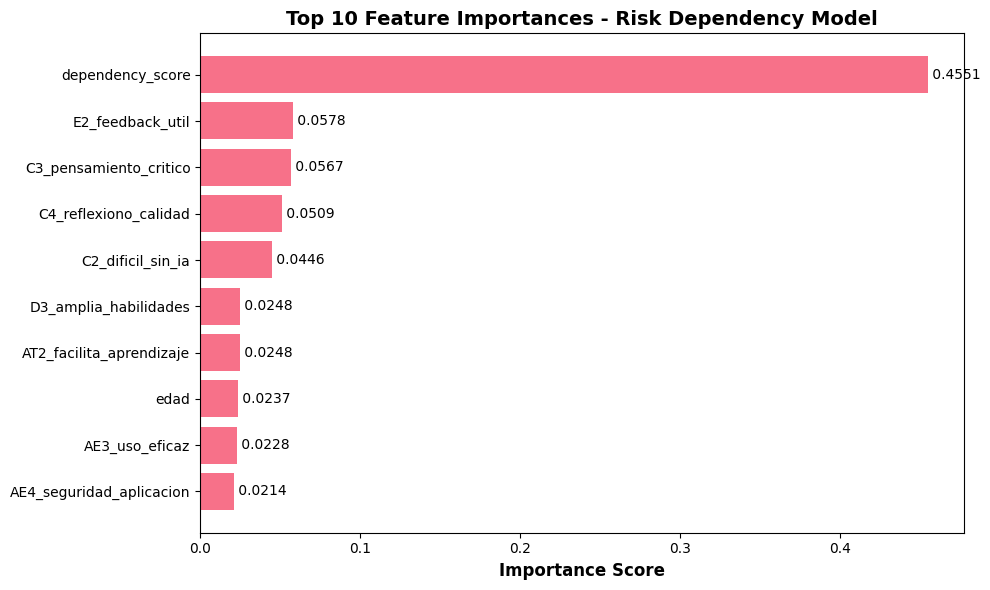

Feature importance plot generated successfully!


In [11]:
# Plot feature importance
fig, ax = plt.subplots(figsize=(10, 6))

# Plot top 10 features
top_n = 10
top_features = feature_importances.head(top_n)

bars = ax.barh(range(len(top_features)), top_features['importance'].values)
ax.set_yticks(range(len(top_features)))
ax.set_yticklabels(top_features['feature'].values)
ax.set_xlabel('Importance Score', fontsize=12, fontweight='bold')
ax.set_title('Top 10 Feature Importances - Risk Dependency Model', fontsize=14, fontweight='bold')
ax.invert_yaxis()

# Add value labels on bars
for i, (idx, row) in enumerate(top_features.iterrows()):
    ax.text(row['importance'], i, f" {row['importance']:.4f}", va='center')

plt.tight_layout()
plt.show()

print("Feature importance plot generated successfully!")

In [12]:
# Save trained model to backend/ml/models/risk_dependency_model.pkl
# Use absolute path since __file__ is not defined in Jupyter notebooks
model_dir = '/workspaces/EvaluAI/backend/ml/models'
os.makedirs(model_dir, exist_ok=True)

In [13]:
# Determine the model save path using absolute path
# (MODEL_PATH env var may not be available in nbconvert execution)
model_dir = '/workspaces/EvaluAI/backend/ml/models'
os.makedirs(model_dir, exist_ok=True)

model_path = os.path.join(model_dir, "risk_dependency_model.pkl")

# Save the trained model using joblib
try:
    joblib.dump(rf_model, model_path)
    print(f"✓ Model saved successfully to: {model_path}")
    print(f"  File size: {os.path.getsize(model_path) / 1024:.2f} KB")
except Exception as e:
    print(f"✗ Error saving model: {e}")
    raise

✓ Model saved successfully to: /workspaces/EvaluAI/backend/ml/models/risk_dependency_model.pkl


  File size: 95.18 KB


In [14]:
# Verification: Load and test the saved model
print("\n" + "="*60)
print("VERIFICATION: Testing Saved Model")
print("="*60)

# Load the saved model
loaded_model = joblib.load(model_path)
print(f"✓ Model loaded successfully from: {model_path}")

# Make predictions with the loaded model
predictions = loaded_model.predict(X)
probabilities = loaded_model.predict_proba(X)

# Calculate metrics on full dataset
accuracy = accuracy_score(y, predictions)
precision = precision_score(y, predictions, zero_division=0)
recall = recall_score(y, predictions, zero_division=0)
roc_auc = roc_auc_score(y, probabilities[:, 1])

print(f"\nPerformance on full dataset:")
print(f"  Accuracy:  {accuracy:.4f}")
print(f"  Precision: {precision:.4f}")
print(f"  Recall:    {recall:.4f}")
print(f"  ROC-AUC:   {roc_auc:.4f}")
print(f"\n✓ Model verification completed successfully!")


VERIFICATION: Testing Saved Model
✓ Model loaded successfully from: /workspaces/EvaluAI/backend/ml/models/risk_dependency_model.pkl

Performance on full dataset:
  Accuracy:  1.0000
  Precision: 1.0000
  Recall:    1.0000
  ROC-AUC:   1.0000

✓ Model verification completed successfully!
